Chapter 30
# 一元OLS线性回归
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

因变量 (dependent variable) 也叫被解释变量 (explained variable)、或回归子
(regressand)、内生变量 (endogenous variable)、响应变量 (response variable)。
在一元线性回归中，我们试图找到一条直线，该直线最好地拟合了自变量和因变量之间的数据关
系。
具体来说，我们要找到一条直线，使得所有数据点到这条直线的垂直距离之差 (残差) 平方和最
小化。
残差项 (residuals) 也叫误差项 (error term)、干扰项 (disturbance term)或噪音项
(noise term)。图 2 中灰色线段便代表残差。
如图 3 所示，残差平方和代表图中所有蓝色正方形的面积。这些蓝色正方形的边长便是残差。这种
方法叫做最小二乘法 (Ordinary Least Square, OLS)。

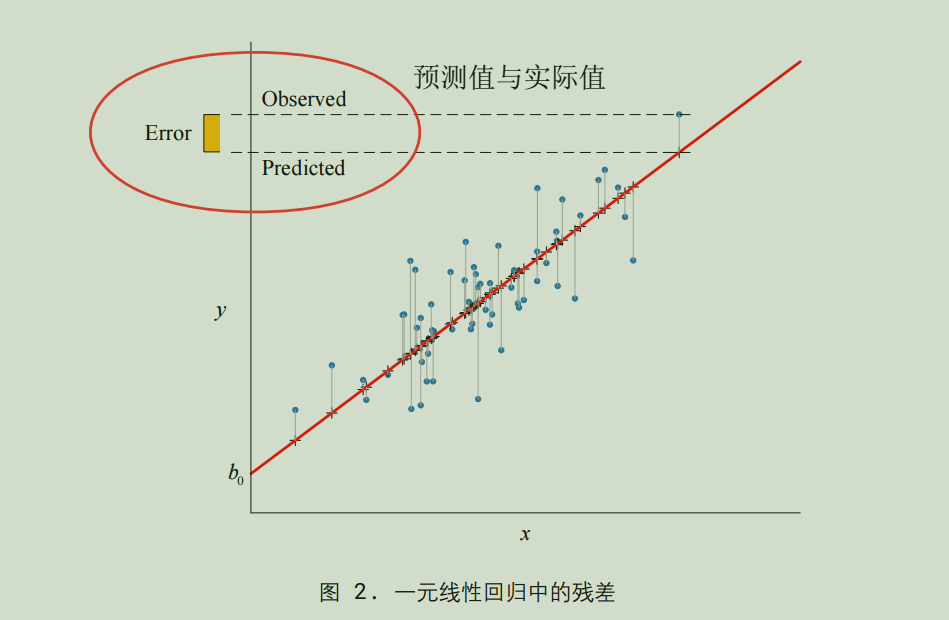

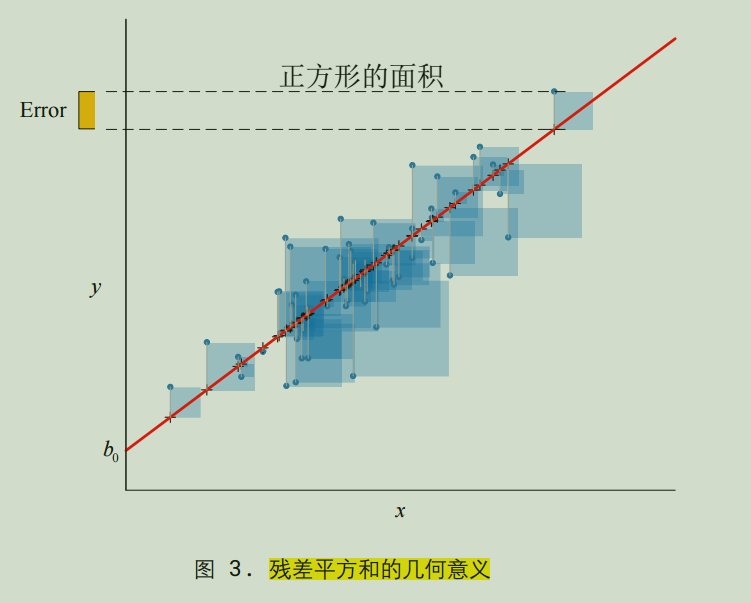

线性回归 (linear regression) 并不适合所有回归分析；很多时候，我们还需
要非线性回归 (nonlinear regression)。
非线性回归是指自变量和因变量之间存在着非线性关系 (nonlinear relation) 的回归模型。
在非线性回归中，自变量和因变量的关系不再是简单的线性关系，而可能是多项式关系、指数关系、对
数关系等其他非线性形式。
非线性回归可以通过拟合曲线或曲面来捕捉数据的非线性关系。本章后续将会介绍多项式回归、逻
辑回归两种非线性回归。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 生成数据

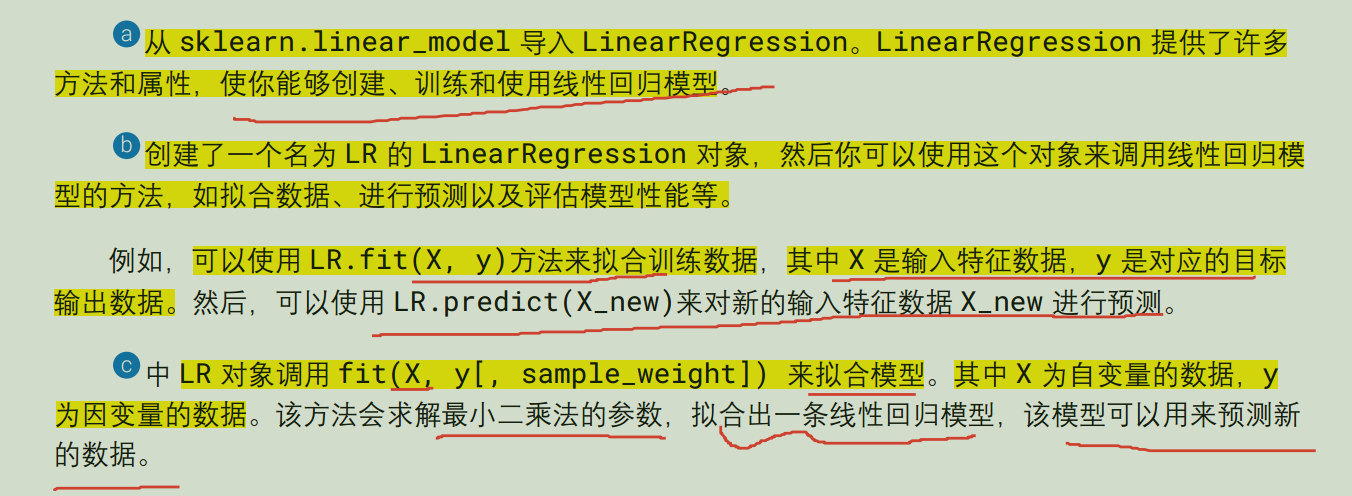

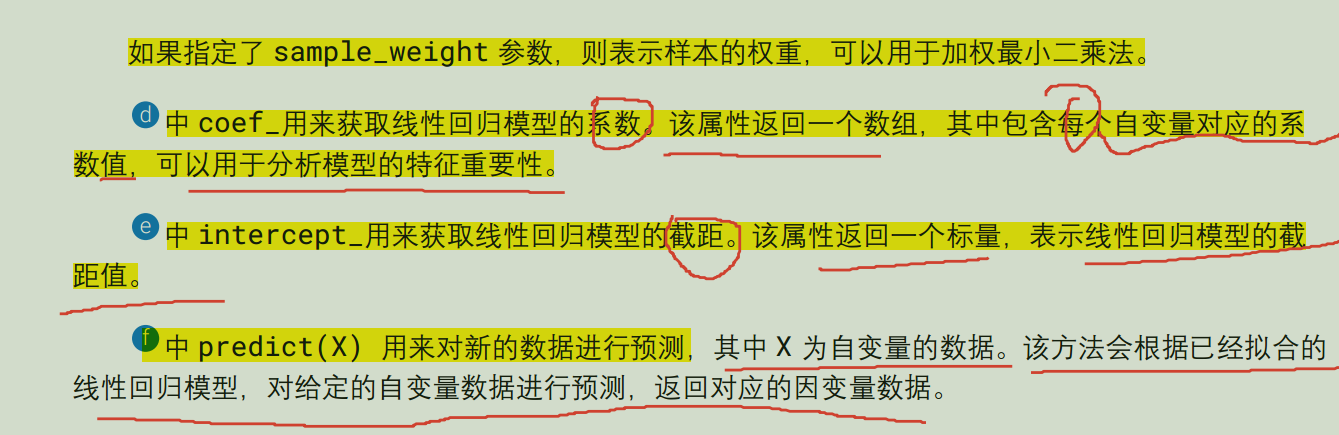

In [2]:
# 生成随机数据
num = 50 # 样本数量
np.random.seed(0) # 随机种子
x_data = np.random.uniform(0,10,num) # 均匀分布取50个数据
y_data = 0.5 * x_data + 1 + np.random.normal(0, 1, num) #原始:y=0.5x + 1  添加随机的干扰项


In [3]:
x_data


array([5.48813504, 7.15189366, 6.02763376, 5.44883183, 4.23654799,
       6.45894113, 4.37587211, 8.91773001, 9.63662761, 3.83441519,
       7.91725038, 5.2889492 , 5.68044561, 9.25596638, 0.71036058,
       0.871293  , 0.20218397, 8.32619846, 7.78156751, 8.70012148,
       9.78618342, 7.99158564, 4.61479362, 7.80529176, 1.18274426,
       6.39921021, 1.43353287, 9.44668917, 5.21848322, 4.1466194 ,
       2.64555612, 7.74233689, 4.56150332, 5.68433949, 0.187898  ,
       6.17635497, 6.12095723, 6.16933997, 9.43748079, 6.81820299,
       3.59507901, 4.37031954, 6.97631196, 0.60225472, 6.66766715,
       6.7063787 , 2.10382561, 1.28926298, 3.15428351, 3.63710771])

In [4]:
x_data = x_data.reshape((-1, 1))
# 将x调整为列向量

In [5]:
# 将两列数据组合在一起；每行就是一个点
data = np.column_stack([x_data,y_data])

In [6]:
data

array([[ 5.48813504,  2.03779733],
       [ 7.15189366,  6.52672223],
       [ 6.02763376,  3.5041647 ],
       [ 5.44883183,  3.28634161],
       [ 4.23654799,  1.86547864],
       [ 6.45894113,  5.00696092],
       [ 4.37587211,  1.57403821],
       [ 8.91773001,  5.24612472],
       [ 9.63662761,  4.92284724],
       [ 3.83441519,  3.30411009],
       [ 7.91725038,  4.44782005],
       [ 5.2889492 ,  2.46384241],
       [ 5.68044561,  3.81204058],
       [ 9.25596638,  6.05631506],
       [ 0.71036058,  1.42169751],
       [ 0.871293  ,  1.7381184 ],
       [ 0.20218397,  0.46676989],
       [ 8.32619846,  4.80035806],
       [ 7.78156751,  4.21832331],
       [ 8.70012148,  4.99050758],
       [ 9.78618342,  5.07994543],
       [ 7.99158564,  3.26951022],
       [ 4.61479362,  3.48482295],
       [ 7.80529176,  4.50086495],
       [ 1.18274426, -0.03882622],
       [ 6.39921021,  4.66238736],
       [ 1.43353287,  0.80946807],
       [ 9.44668917,  5.77528998],
       [ 5.21848322,

# 创建回归对象并进行拟合

In [8]:
# 创建回归对象并进行拟合
LR = LinearRegression()
# 使用LinearRegression()构建了一个线性回归模型
print(LR)
LR.fit(x_data, y_data) # 进行数据拟合

LinearRegression()


LinearRegression()

## 获取斜率与截距

In [9]:
slope = LR.coef_ # 斜率
intercept = LR.intercept_ # 截距

In [12]:
slope

array([0.46927329])

In [10]:
print(slope, intercept)

[0.46927329] 0.992789915869722


## 生成一系列点；转为列向量

In [13]:
x_array = np.linspace(0,10,101).reshape((-1, 1))
# 预测
predicted = LR.predict(x_array) # 进行预测；进行绘制曲线

In [14]:
predicted

array([0.99278992, 1.03971725, 1.08664457, 1.1335719 , 1.18049923,
       1.22742656, 1.27435389, 1.32128122, 1.36820855, 1.41513588,
       1.46206321, 1.50899054, 1.55591787, 1.6028452 , 1.64977253,
       1.69669986, 1.74362719, 1.79055452, 1.83748185, 1.88440918,
       1.93133651, 1.97826383, 2.02519116, 2.07211849, 2.11904582,
       2.16597315, 2.21290048, 2.25982781, 2.30675514, 2.35368247,
       2.4006098 , 2.44753713, 2.49446446, 2.54139179, 2.58831912,
       2.63524645, 2.68217378, 2.72910111, 2.77602844, 2.82295577,
       2.86988309, 2.91681042, 2.96373775, 3.01066508, 3.05759241,
       3.10451974, 3.15144707, 3.1983744 , 3.24530173, 3.29222906,
       3.33915639, 3.38608372, 3.43301105, 3.47993838, 3.52686571,
       3.57379304, 3.62072037, 3.6676477 , 3.71457503, 3.76150235,
       3.80842968, 3.85535701, 3.90228434, 3.94921167, 3.996139  ,
       4.04306633, 4.08999366, 4.13692099, 4.18384832, 4.23077565,
       4.27770298, 4.32463031, 4.37155764, 4.41848497, 4.46541

## 将数据与预测值组合在一起

In [16]:
data_ = np.column_stack([x_data,LR.predict(x_data)])

In [17]:
data

array([[ 5.48813504,  2.03779733],
       [ 7.15189366,  6.52672223],
       [ 6.02763376,  3.5041647 ],
       [ 5.44883183,  3.28634161],
       [ 4.23654799,  1.86547864],
       [ 6.45894113,  5.00696092],
       [ 4.37587211,  1.57403821],
       [ 8.91773001,  5.24612472],
       [ 9.63662761,  4.92284724],
       [ 3.83441519,  3.30411009],
       [ 7.91725038,  4.44782005],
       [ 5.2889492 ,  2.46384241],
       [ 5.68044561,  3.81204058],
       [ 9.25596638,  6.05631506],
       [ 0.71036058,  1.42169751],
       [ 0.871293  ,  1.7381184 ],
       [ 0.20218397,  0.46676989],
       [ 8.32619846,  4.80035806],
       [ 7.78156751,  4.21832331],
       [ 8.70012148,  4.99050758],
       [ 9.78618342,  5.07994543],
       [ 7.99158564,  3.26951022],
       [ 4.61479362,  3.48482295],
       [ 7.80529176,  4.50086495],
       [ 1.18274426, -0.03882622],
       [ 6.39921021,  4.66238736],
       [ 1.43353287,  0.80946807],
       [ 9.44668917,  5.77528998],
       [ 5.21848322,

# 绘制图像

(-2.0, 8.0)

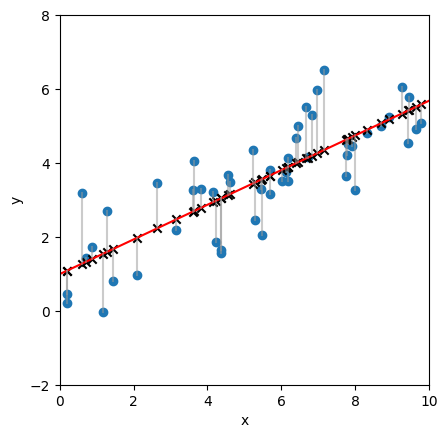

In [18]:
fig, ax = plt.subplots()
# 绘制散点图；原始数据
ax.scatter(x_data, y_data)

# 绘制散点图；预测数据
# x 在 回归线的点
ax.scatter(x_data, LR.predict(x_data),
            color = 'k', marker = 'x')
# 绘制回归线
ax.plot(x_array, predicted,
        color = 'r')

# 连接原始点与预测点
ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
         ([j for (i,j) in data_], [j for (i,j) in data]),
         c=[0.6,0.6,0.6], alpha = 0.5)

ax.set_xlabel('x'); ax.set_ylabel('y') # 标签
ax.set_aspect('equal', adjustable='box') # x,y轴比例一致
ax.set_xlim(0,10); ax.set_ylim(-2,8) # 范围